<a href="https://colab.research.google.com/github/teemus28/Machine-Learning/blob/main/Gradient_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gradient Descent Algorithm - regression data

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
np.random.seed(42)         # this will generate same set of random numbers if we use the same seed 7

X = np.random.rand(100,1) - 0.5              # generate array of random numbers between 0-1 of dimension 100X1
y = 3*X[:,0]**2 + 0.05*np.random.randn(100)               # randn generate random numbers having -  mean 0 and standard deviation 1

In [ ]:
df = pd.DataFrame()

df['X'] = X.reshape(100)       #make it 1d array
df['y'] = y

In [ ]:
df

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


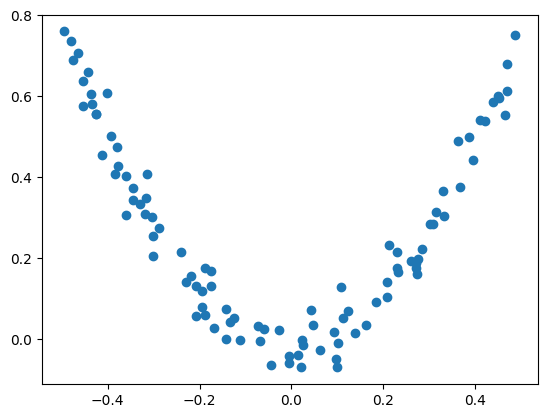

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['X'],df['y'])

In [ ]:
# assume - pred1 = mean

df['y_pred'] = df['y'].mean()

In [ ]:
df

,X,y,y_pred
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458
...,...,...,...
95,-0.006204,-0.040675,0.265458
96,0.022733,-0.002305,0.265458
97,-0.072459,0.032809,0.265458
98,-0.474581,0.689516,0.265458


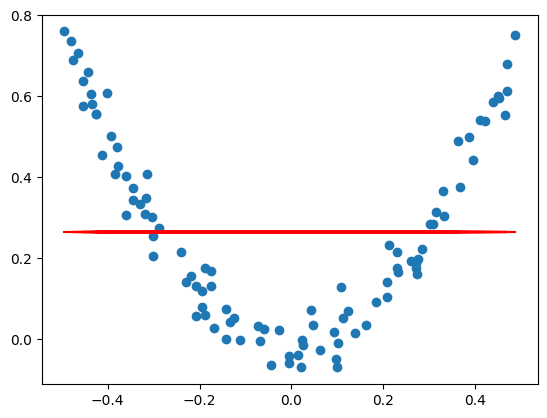

In [ ]:
plt.scatter(df['X'],df['y'])
plt.plot(df['X'],df['y_pred'],c='r')

In [ ]:
#2 residual = y - y_pred

df['res_1'] = df['y'] - df['y_pred']

In [ ]:
df

,X,y,y_pred,res_1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528
...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133
96,0.022733,-0.002305,0.265458,-0.267763
97,-0.072459,0.032809,0.265458,-0.232650
98,-0.474581,0.689516,0.265458,0.424057


In [ ]:
#step3 - train (X,res1) with DT of leaf node between 8-32

from sklearn.tree import DecisionTreeRegressor

tree1 = DecisionTreeRegressor(max_leaf_nodes=8)

In [ ]:
tree1.fit(df['X'].values.reshape(100,1),df['res_1'].values)       #it takes i/p as array

DecisionTreeRegressor(max_leaf_nodes=8)

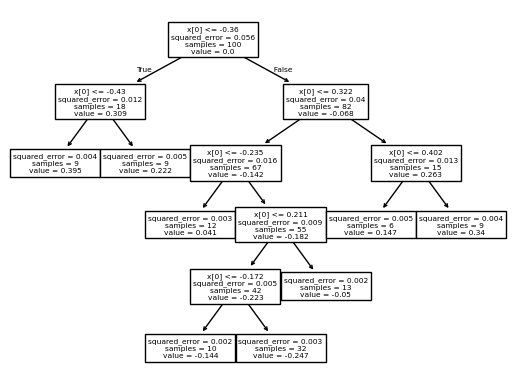

In [ ]:
from sklearn.tree import plot_tree
plot_tree(tree1)
plt.show()

In [ ]:
# plotting prediction

X_test = np.linspace(-0.5,0.5,100)
pred = tree1.predict(X_test.reshape(-1,1))        # reshapes an array into a 2D array with one column


In [ ]:
pred1 = df['y_pred'] + pred

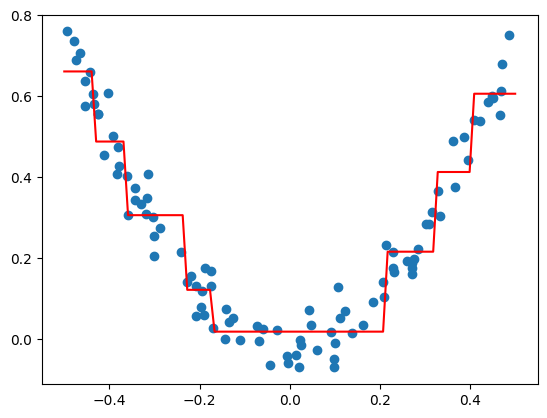

In [ ]:
plt.scatter(df['X'],df['y'])
plt.plot(X_test,pred1,c='r')

In [ ]:
#step4 - y_pred2 = (y_pred1 + tree1_prediction of (X,res1))

df['y_pred_2'] = df['y_pred'] + tree1.predict(df['X'].values.reshape(100,1))

In [ ]:
df

,X,y,y_pred,res_1,y_pred_2
0,-0.125460,0.051573,0.265458,-0.213885,0.018320
1,0.450714,0.594480,0.265458,0.329021,0.605884
2,0.231994,0.166052,0.265458,-0.099407,0.215784
3,0.098658,-0.070178,0.265458,-0.335636,0.018320
4,-0.343981,0.343986,0.265458,0.078528,0.305965
...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018320
96,0.022733,-0.002305,0.265458,-0.267763,0.018320
97,-0.072459,0.032809,0.265458,-0.232650,0.018320
98,-0.474581,0.689516,0.265458,0.424057,0.660912


In [ ]:
df['res_2'] = df['y'] - df['y_pred_2']

In [ ]:
df

,X,y,y_pred,res_1,y_pred_2,res_2
0,-0.125460,0.051573,0.265458,-0.213885,0.018320,0.033253
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,0.018320,-0.088497
4,-0.343981,0.343986,0.265458,0.078528,0.305965,0.038021
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018320,-0.058995
96,0.022733,-0.002305,0.265458,-0.267763,0.018320,-0.020624
97,-0.072459,0.032809,0.265458,-0.232650,0.018320,0.014489
98,-0.474581,0.689516,0.265458,0.424057,0.660912,0.028603


In [ ]:
#5 train (X,res2)

In [ ]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)

In [ ]:
tree2.fit(df['X'].values.reshape(100,1),df['res_2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [ ]:
pred2 = df['y_pred'] + sum(regressor.predict(X_test.reshape(-1, 1)) for regressor in [tree1,tree2])

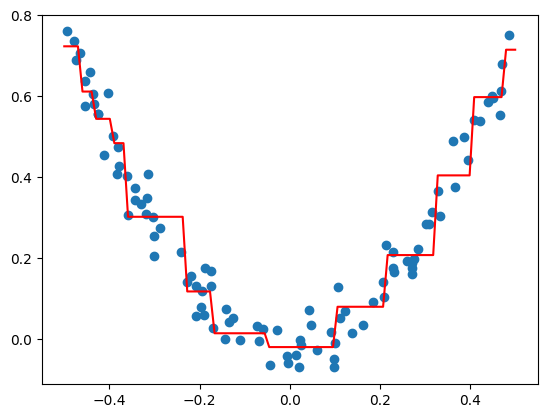

In [ ]:
plt.scatter(df['X'],df['y'])
plt.plot(X_test,pred2,c='r')

In [ ]:
#pred3 = mean + prediction of (X,res1) + prediction of (X,res2)

df['y_pred_3'] = df['y_pred'] + tree1.predict(df['X'].values.reshape(100,1)) + tree2.predict(df['X'].values.reshape(100,1))

In [ ]:
df

,X,y,y_pred,res_1,y_pred_2,res_2,y_pred_3
0,-0.125460,0.051573,0.265458,-0.213885,0.018320,0.033253,0.014321
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404,0.597523
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732,0.207423
3,0.098658,-0.070178,0.265458,-0.335636,0.018320,-0.088497,-0.019811
4,-0.343981,0.343986,0.265458,0.078528,0.305965,0.038021,0.301966
...,...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018320,-0.058995,-0.019811
96,0.022733,-0.002305,0.265458,-0.267763,0.018320,-0.020624,-0.019811
97,-0.072459,0.032809,0.265458,-0.232650,0.018320,0.014489,0.014321
98,-0.474581,0.689516,0.265458,0.424057,0.660912,0.028603,0.722987


In [ ]:
# Now continue this steps for more trees

In [ ]:
# data - X,y
# number of times - number
# list of DT's - regs
# prediction - foo



# conditions -
# 1.number = 0 , return None
# 2 number = 1 , return y
# 3 number > 1  , Algorithm

In [ ]:
def gradient_boost(X,y,number,lr,count=1,regs=[],foo=None):

  if number == 0:
    return
  else:
    # do gradient boosting

    if count > 1:
      y = y - regs[-1].predict(X)
    else:
      foo = y

    tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree_reg.fit(X, y)

    regs.append(tree_reg)

    x1 = np.linspace(-0.5, 0.5, 500)

    y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

    print(number)
    plt.figure()
    plt.plot(x1, y_pred, linewidth=2)
    plt.plot(X[:, 0], foo,"r.")
    plt.show()

    gradient_boost(X,y,number-1,lr,count+1,regs,foo=foo)

10


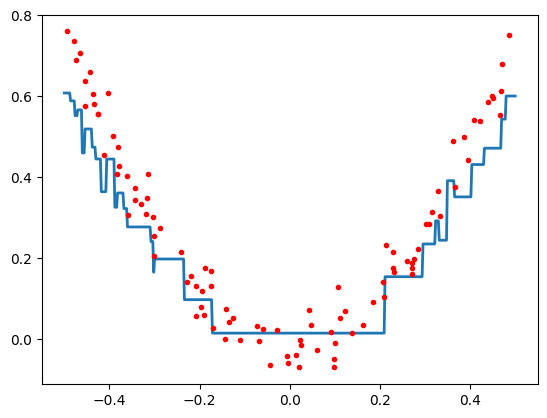

9


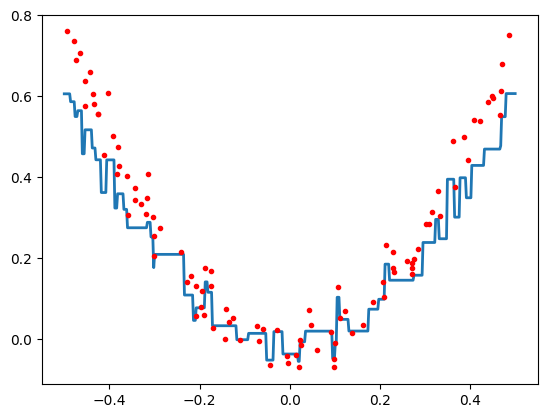

8


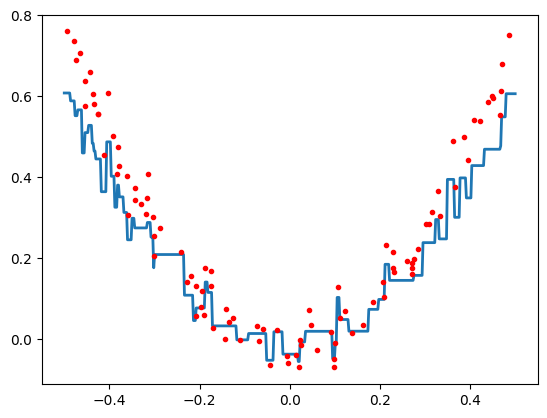

7


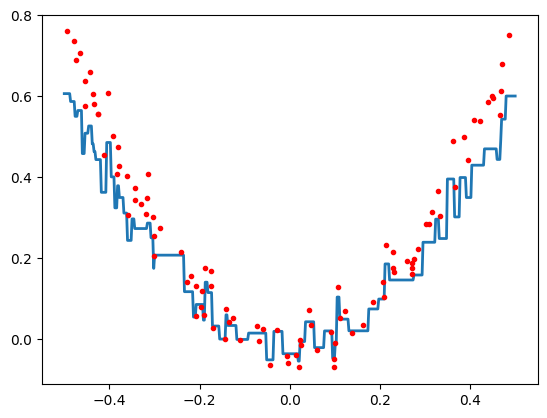

6


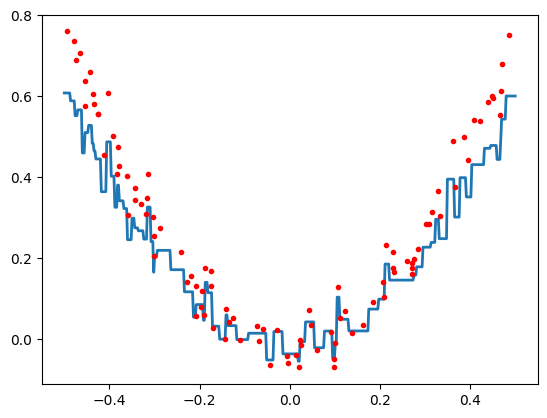

5


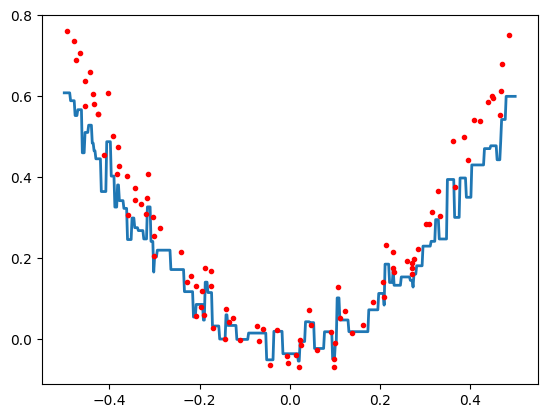

4


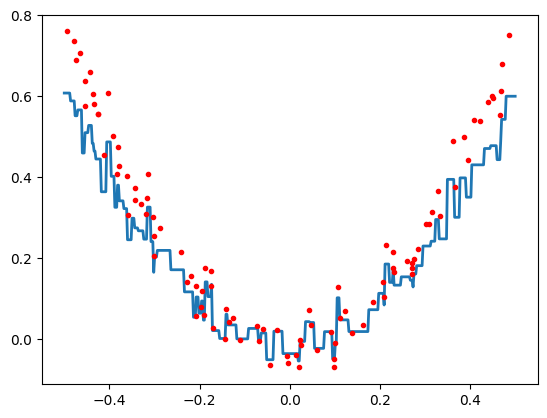

3


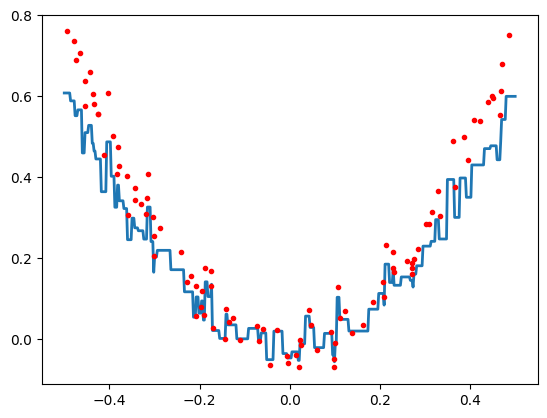

2


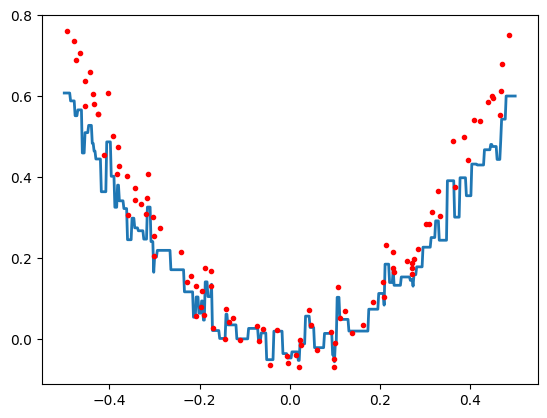

1


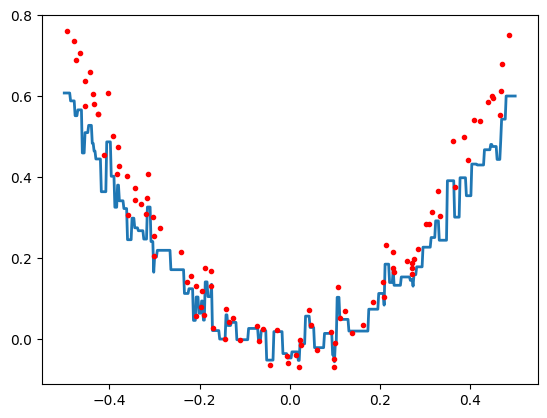

In [ ]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)
gradient_boost(X,y,10,lr=.8)

# Gradient Boosting for classification data

In [ ]:
df = pd.DataFrame(
                  [
                      [6.82, 118, 0],
                      [6.36, 125, 1],
                      [5.39, 99, 1],
                      [5.50, 106, 1],
                      [6.39, 148, 0],
                      [9.13, 148, 1],
                      [7.17, 147, 1],
                      [7.72, 72, 0]
                   ], columns = ['cgpa',	'iq',	'is_placed']
)

In [ ]:
df

,cgpa,iq,is_placed
0,6.82,118,0
1,6.36,125,1
2,5.39,99,1
3,5.50,106,1
4,6.39,148,0
5,9.13,148,1
6,7.17,147,1
7,7.72,72,0


In [ ]:
#step1 , initial prediction - log(Y/N)

df['pred1(log(odds))'] = np.log(5/3)

In [ ]:
df

,cgpa,iq,is_placed,pred1(log(odds))
0,6.82,118,0,0.510826
1,6.36,125,1,0.510826
2,5.39,99,1,0.510826
3,5.50,106,1,0.510826
4,6.39,148,0,0.510826
5,9.13,148,1,0.510826
6,7.17,147,1,0.510826
7,7.72,72,0,0.510826


In [ ]:
# convert log odds to probability

df['pred1(probability)'] = 1/(1+np.exp(-np.log(5/3)))

In [ ]:
df

,cgpa,iq,is_placed,pred1(log(odds)),pred1(probability)
0,6.82,118,0,0.510826,0.625
1,6.36,125,1,0.510826,0.625
2,5.39,99,1,0.510826,0.625
3,5.50,106,1,0.510826,0.625
4,6.39,148,0,0.510826,0.625
5,9.13,148,1,0.510826,0.625
6,7.17,147,1,0.510826,0.625
7,7.72,72,0,0.510826,0.625


In [ ]:
#step2 - res1 = actual-pred1

df['res1'] = df['is_placed'] - df['pred1(probability)']

In [ ]:
df

,cgpa,iq,is_placed,pred1(log(odds)),pred1(probability),res1
0,6.82,118,0,0.510826,0.625,-0.625
1,6.36,125,1,0.510826,0.625,0.375
2,5.39,99,1,0.510826,0.625,0.375
3,5.50,106,1,0.510826,0.625,0.375
4,6.39,148,0,0.510826,0.625,-0.625
5,9.13,148,1,0.510826,0.625,0.375
6,7.17,147,1,0.510826,0.625,0.375
7,7.72,72,0,0.510826,0.625,-0.625


In [ ]:
# step 3 - train (X,res1)

from sklearn.tree import DecisionTreeRegressor
reg_1 = DecisionTreeRegressor(max_leaf_nodes=3)


In [ ]:
reg_1.fit(df.iloc[:,0:2].values, df.iloc[:,-1].values)

DecisionTreeRegressor(max_leaf_nodes=3)

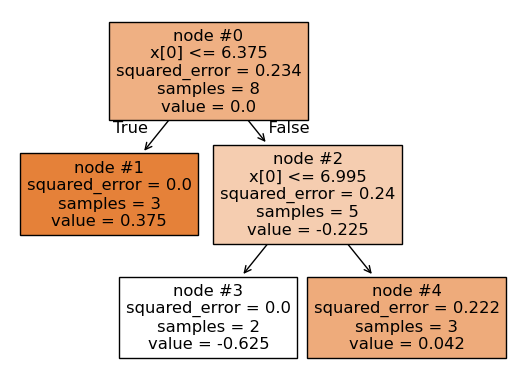

In [ ]:
from sklearn.tree import plot_tree

plot_tree(reg_1,filled=True, node_ids=True)
plt.show()

In [ ]:
#https://inoxoft.com/blog/gradient-boosting-classifier-inoxoft/